In [1]:
#Importación librerías generales
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [2]:
#Importación de Machin Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Modelo
from sklearn.linear_model import LogisticRegression

# Métricas
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    roc_auc_score,
    roc_curve
)

In [3]:
#Ruta
os.chdir(r"C:\Users\Nefi\OneDrive\Documentos\09-EBAC\EBACMX-DATA-ANALYST\Referencias")

#Cargar datos
df = pd.read_csv("general_data_.csv")

#Visualización inicial
df.head()

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeID,Gender,...,NumCompaniesWorked,Over18,PercentSalaryHike,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager
0,51,No,Travel_Rarely,Sales,6,2,Life Sciences,1,1,Female,...,1.0,Y,11,8,0,1.0,6,1,0,0
1,31,Yes,Travel_Frequently,Research & Development,10,1,Life Sciences,1,2,Female,...,0.0,Y,23,8,1,6.0,3,5,1,4
2,32,No,Travel_Frequently,Research & Development,17,4,Other,1,3,Male,...,1.0,Y,15,8,3,5.0,2,5,0,3
3,38,No,Non-Travel,Research & Development,2,5,Life Sciences,1,4,Male,...,3.0,Y,11,8,3,13.0,5,8,7,5
4,32,No,Travel_Rarely,Research & Development,10,1,Medical,1,5,Male,...,4.0,Y,12,8,2,9.0,2,6,0,4


In [4]:
#EDA-Información general
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      4410 non-null   int64  
 1   Attrition                4410 non-null   object 
 2   BusinessTravel           4410 non-null   object 
 3   Department               4410 non-null   object 
 4   DistanceFromHome         4410 non-null   int64  
 5   Education                4410 non-null   int64  
 6   EducationField           4410 non-null   object 
 7   EmployeeCount            4410 non-null   int64  
 8   EmployeeID               4410 non-null   int64  
 9   Gender                   4410 non-null   object 
 10  JobLevel                 4410 non-null   int64  
 11  JobRole                  4410 non-null   object 
 12  MaritalStatus            4410 non-null   object 
 13  MonthlyIncome            4410 non-null   int64  
 14  NumCompaniesWorked      

,Age,DistanceFromHome,Education,EmployeeCount,EmployeeID,JobLevel,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager
count,4410.000000,4410.000000,4410.000000,4410.0,4410.000000,4410.000000,4410.000000,4391.000000,4410.000000,4410.0,4410.000000,4401.000000,4410.000000,4410.000000,4410.000000,4410.000000
mean,36.923810,9.192517,2.912925,1.0,2205.500000,2.063946,65029.312925,2.694830,15.209524,8.0,0.793878,11.279936,2.799320,7.008163,2.187755,4.123129
std,9.133301,8.105026,1.023933,0.0,1273.201673,1.106689,47068.888559,2.498887,3.659108,0.0,0.851883,7.782222,1.288978,6.125135,3.221699,3.567327
min,18.000000,1.000000,1.000000,1.0,1.000000,1.000000,10090.000000,0.000000,11.000000,8.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,2.000000,2.000000,1.0,1103.250000,1.000000,29110.000000,1.000000,12.000000,8.0,0.000000,6.000000,2.000000,3.000000,0.000000,2.000000
50%,36.000000,7.000000,3.000000,1.0,2205.500000,2.000000,49190.000000,2.000000,14.000000,8.0,1.000000,10.000000,3.000000,5.000000,1.000000,3.000000
75%,43.000000,14.000000,4.000000,1.0,3307.750000,3.000000,83800.000000,4.000000,18.000000,8.0,1.000000,15.000000,3.000000,9.000000,3.000000,7.000000
max,60.000000,29.000000,5.000000,1.0,4410.000000,5.000000,199990.000000,9.000000,25.000000,8.0,3.000000,40.000000,6.000000,40.000000,15.000000,17.000000


In [5]:
#EDA-Valores nulos
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeID                  0
Gender                      0
JobLevel                    0
JobRole                     0
MaritalStatus               0
MonthlyIncome               0
NumCompaniesWorked         19
Over18                      0
PercentSalaryHike           0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           9
TrainingTimesLastYear       0
YearsAtCompany              0
YearsSinceLastPromotion     0
YearsWithCurrManager        0
dtype: int64

In [6]:
#EDA-Nulos por valores de media
df.fillna(df.median(numeric_only=True), inplace=True)

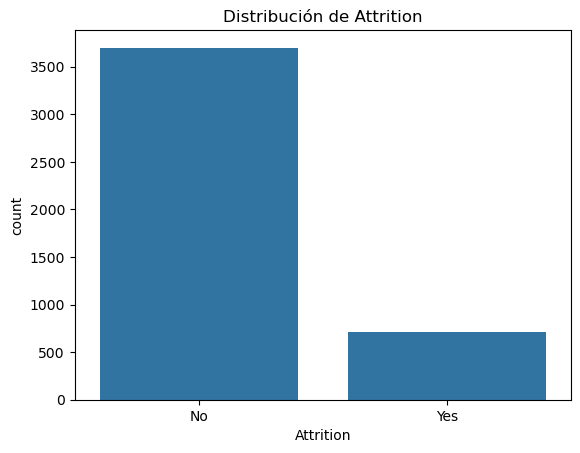

In [7]:
#Distribución de la variable
sns.countplot(x='Attrition', data=df)

plt.title("Distribución de Attrition")
plt.show()

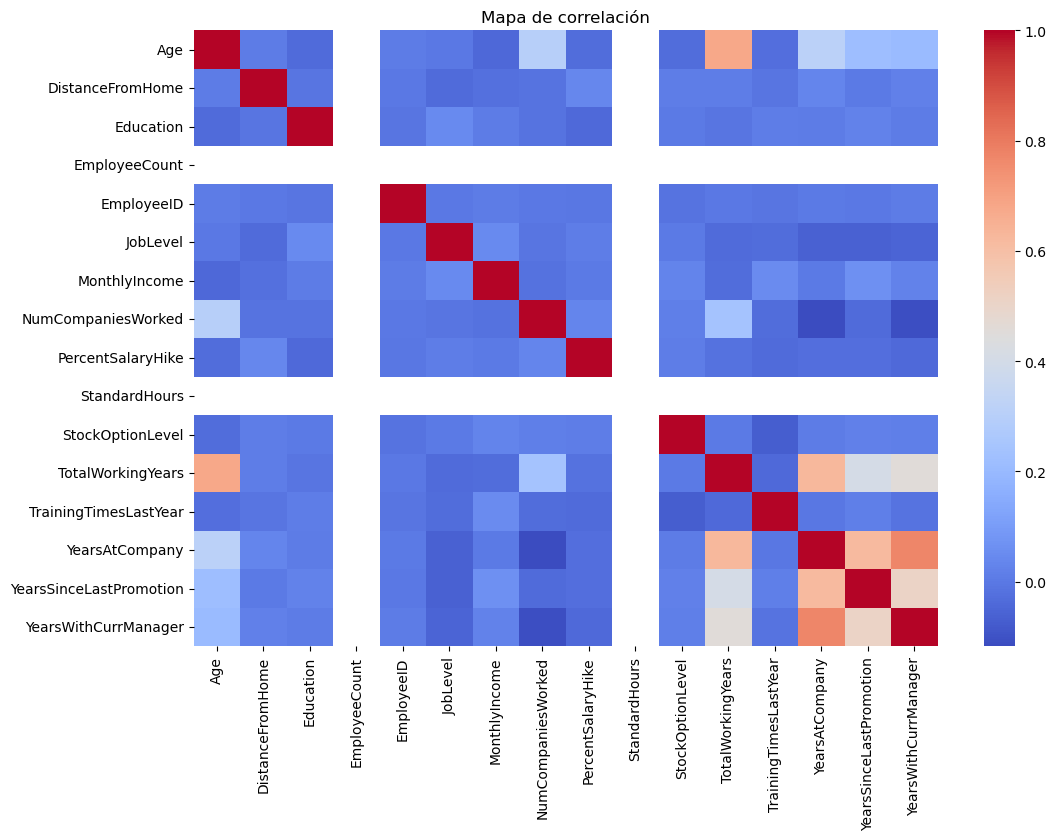

In [8]:
#Análisis de correlación
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")

plt.title("Mapa de correlación")

plt.show()

In [9]:
#ML-Conversión de variables
df["Attrition"] = df["Attrition"].map({
    "Yes":1,
    "No":0
})

In [10]:
#ML-Eliminación de variables
df.drop(["EmployeeID","EmployeeCount","StandardHours","Over18"], axis=1, inplace=True)

In [11]:
#ML-Creación de variable Ingreso por año de trabajo
df["IncomePerYearWorked"] = df["MonthlyIncome"] / (df["TotalWorkingYears"] + 1)

In [12]:
#ML-Transformación a dummies
df = pd.get_dummies(df, drop_first=True)

In [13]:
#Distribución
X = df.drop("Attrition", axis=1)

y = df["Attrition"]

In [14]:
#Estandarización
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [15]:
#División entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
#Entrenamiento
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [17]:
#Predicciones
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]

In [18]:
#Evaluación
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8378684807256236


In [19]:
#Reporte
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.97      0.91       741
           1       0.48      0.16      0.24       141

    accuracy                           0.84       882
   macro avg       0.67      0.56      0.57       882
weighted avg       0.80      0.84      0.80       882



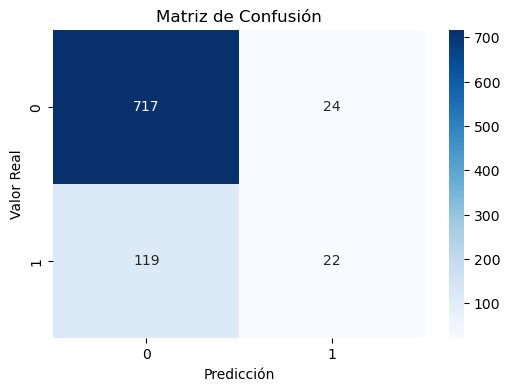

In [20]:
#Matríz de confusión
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(conf_matrix,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.title("Matriz de Confusión")

plt.xlabel("Predicción")

plt.ylabel("Valor Real")

plt.show()

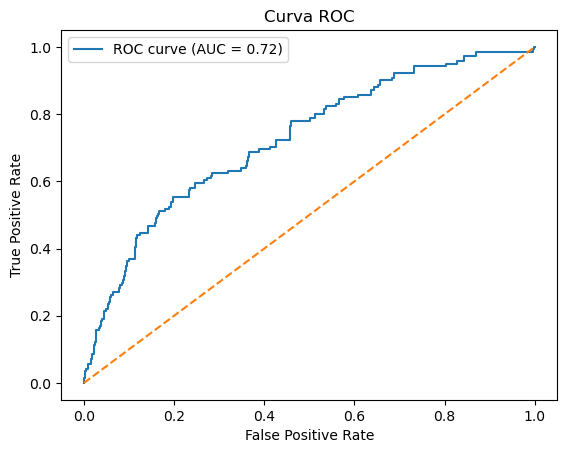

In [21]:
#Curva ROC y AUC
auc = roc_auc_score(y_test, y_prob)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure()

plt.plot(fpr, tpr, label="ROC curve (AUC = %0.2f)" % auc)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("Curva ROC")

plt.legend()

plt.show()

In [22]:
#Análisis de sensibilidad
importance = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": model.coef_[0]
})

importance = importance.sort_values(by="Coeficiente", ascending=False)

importance.head(10)

,Variable,Coeficiente
14,BusinessTravel_Travel_Frequently,0.593240
33,MaritalStatus_Single,0.473286
11,YearsSinceLastPromotion,0.432134
15,BusinessTravel_Travel_Rarely,0.379899
5,NumCompaniesWorked,0.331953
13,IncomePerYearWorked,0.192290
28,JobRole_Research Director,0.137908
29,JobRole_Research Scientist,0.090774
32,MaritalStatus_Married,0.086262
30,JobRole_Sales Executive,0.062216


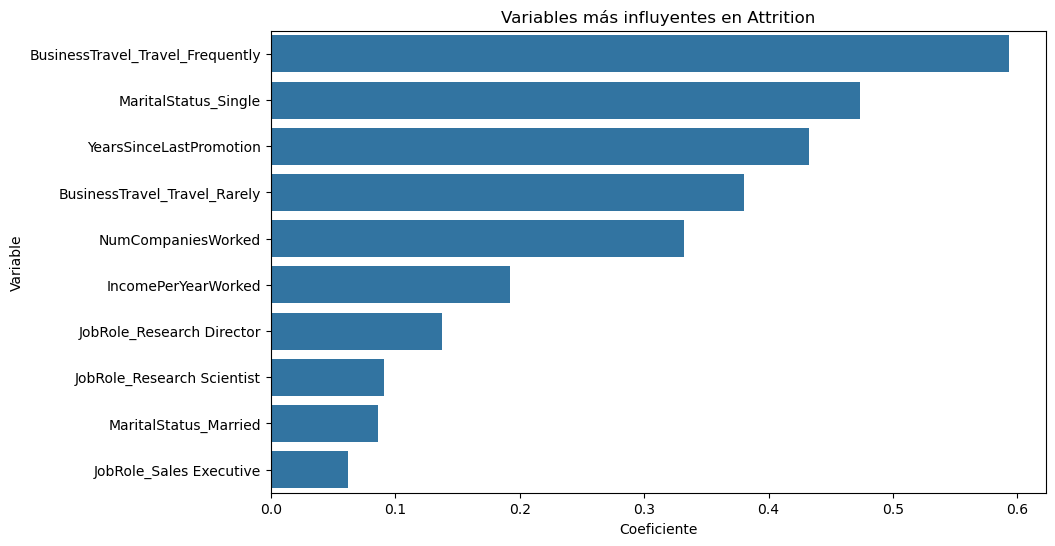

In [23]:
#Visualización de importancia
plt.figure(figsize=(10,6))

sns.barplot(
    x="Coeficiente",
    y="Variable",
    data=importance.head(10)
)

plt.title("Variables más influyentes en Attrition")

plt.show()

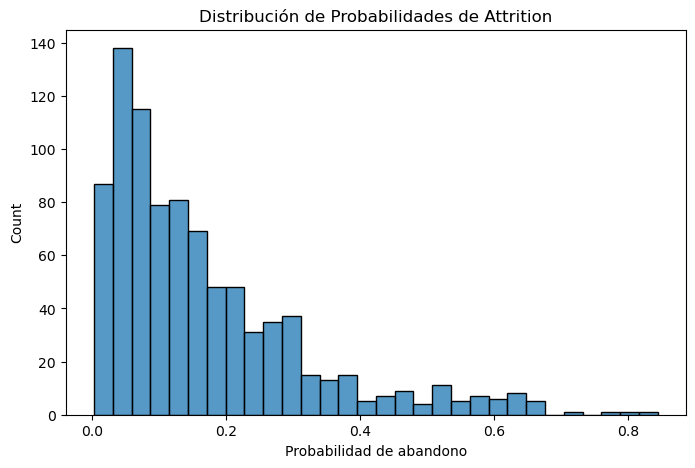

In [24]:
#Probabilidades predichas
plt.figure(figsize=(8,5))

sns.histplot(y_prob, bins=30)

plt.title("Distribución de Probabilidades de Attrition")

plt.xlabel("Probabilidad de abandono")

plt.show()